In [1]:
import numpy as np 
import matplotlib.pyplot as plt


## Ejercicio 19

Considerar un sistema formado por dos especies que compiten por un mismo recurso:

$$
\begin{cases}
\dot{x} = x(\beta - \delta x - \gamma y),\\
\dot{y} = y(b - d y - c x),
\end{cases}
$$

que tiene cuatro equilibrios en los puntos:

$$
O = (0,0), \qquad
P = \left(0,\frac{b}{d}\right), \qquad
Q = \left(\frac{\beta}{\delta},0\right), \qquad
R = \left(\frac{C_2}{C_1}, \frac{C_3}{C_1}\right),
$$

donde

$$
C_1 = \gamma c - \delta d, \qquad
C_2 = \gamma b - \beta d, \qquad
C_3 = \beta c - \delta b.
$$

Observar que para que $R$ esté en el primer cuadrante es necesario que $C_1$, $C_2$ y $C_3$ tengan todos el mismo signo.

**(a)** Interpretar el significado de los parámetros.

**(b)** Realizar diagramas de fase y graficar el campo de velocidades para valores de $C_i$ positivos para todo $i$ y negativos para todo $i$. ¿Qué se observa?

 C1: -0.75, C2:-0.50, C3:-0.50
Equilibrios: [[0.         0.        ]
 [0.         1.        ]
 [1.         0.        ]
 [0.66666667 0.66666667]]


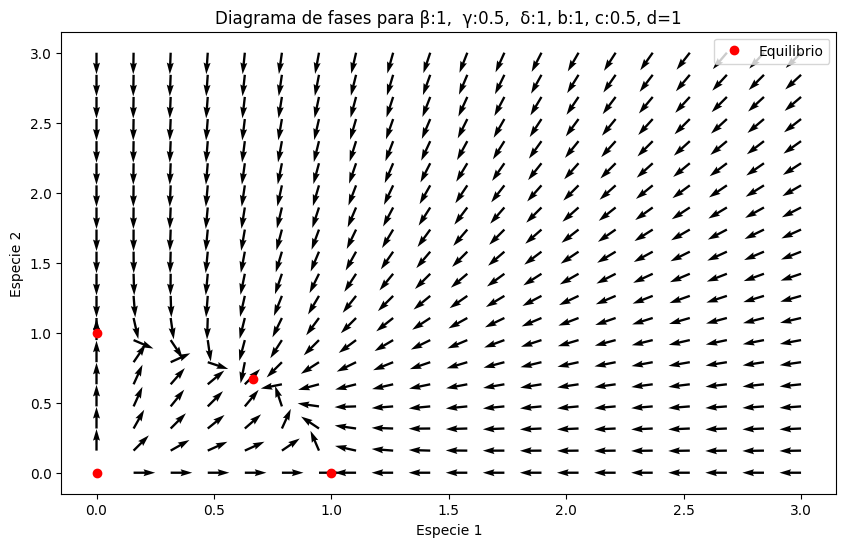

In [24]:
# Parámetros
beta, delta, gamma = 1, 1, 0.5
b, c, d = 1, 0.5, 1

def sistema(estado, parametros):
    x, y = estado
    beta, delta, gamma, b, c, d = parametros
    dXdt = x * (beta - delta*x - gamma*y)
    dYdt = y* (b - d*y - c*x)
    
    return np.array([dXdt, dYdt])

C1, C2, C3 = (gamma*c - delta*d), (gamma*b - beta*d), (beta*c - delta*b)
print(f' C1: {C1:.2f}, C2:{C2:.2f}, C3:{C3:.2f}')

equilibrios = np.array([[0,0], [0, b/d], [beta/delta, 0], [C2/C1, C3/C1]])
print(f'Equilibrios: {equilibrios}')

# Campo vectorial
x_vals = np.linspace(0, 3, 20)
y_vals = np.linspace(0, 3, 20)
X, Y = np.meshgrid(x_vals, y_vals)

U, V = sistema((X,Y), np.array([beta, delta, gamma, b, c, d]))
norma = np.sqrt(U**2 + V**2)
norma[norma==0] = 1
U_norm = U / norma
V_norm = V / norma

plt.figure(figsize=(10,6))
plt.quiver(X, Y, U_norm, V_norm)
for i, eq in enumerate(equilibrios):
    plt.plot(eq[0], eq[1], 'ro', label='Equilibrio' if i == 0 else None)
plt.legend()
plt.xlabel(f'Especie 1')
plt.ylabel(f'Especie 2')
plt.title(f'Diagrama de fases para β:{beta},  γ:{gamma},  δ:{delta}, b:{b}, c:{c}, d={d}')
plt.show()